In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from PIL import Image

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.21.0
NumPy: 2.5.3


Importing dataset with images that have right values matched with them 

In [2]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "emnist/letters",
    as_supervised=True,
    with_info=True
)

In [3]:
print(info)

tfds.core.DatasetInfo(
    name='emnist',
    full_name='emnist/letters/3.1.0',
    description="""
    The EMNIST dataset is a set of handwritten character digits derived from the NIST Special Database 19 and converted to a 28x28 pixel image format and dataset structure that directly matches the MNIST dataset.
    
    Note: Like the original EMNIST data, images provided here are inverted horizontally and rotated 90 anti-clockwise. You can use `tf.transpose` within `ds.map` to convert the images to a human-friendlier format.
    """,
    config_description="""
    EMNIST Letters
    """,
    homepage='https://www.nist.gov/itl/products-and-services/emnist-dataset',
    data_dir='C:\\Users\\fajse\\tensorflow_datasets\\emnist\\letters\\3.1.0',
    file_format=tfrecord,
    download_size=535.73 MiB,
    dataset_size=44.14 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=37),
    }),
    

Gives us specific information about the dataset

Number of examples with examples for model to train on and test with 

In [4]:
print("Training examples:", info.splits["train"].num_examples)
print("Test examples:", info.splits["test"].num_examples)

Training examples: 88800
Test examples: 14800


In [5]:
train_dataset = dataset["train"]

for image, label in train_dataset.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())

Image shape: (28, 28, 1)
Label: 25


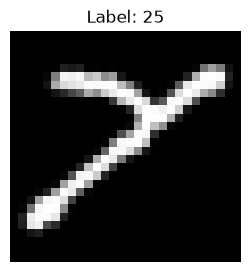

In [6]:
plt.figure(figsize=(3, 3))

plt.imshow(image[:, :, 0], cmap="gray")
plt.title(f"Label: {label.numpy()}")
plt.axis("off")

plt.show()

In [7]:
print(image)

tf.Tensor(
[[[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [  1]
  [  0]
  [  0]
  [  0]]

 [[  0]
  [  0]
  [  0]
  [  0]
  [  0]
  [  1]
  [ 32]
  [ 26]
  [ 32]
  [  3]
  [  

In [8]:
print(image.shape)

(28, 28, 1)


In [9]:
print(image[0, 0, 0])

tf.Tensor(0, shape=(), dtype=uint8)


In [10]:
print("Minimum pixel value:", tf.reduce_min(image).numpy())
print("Maximum pixel value:", tf.reduce_max(image).numpy())

Minimum pixel value: 0
Maximum pixel value: 255


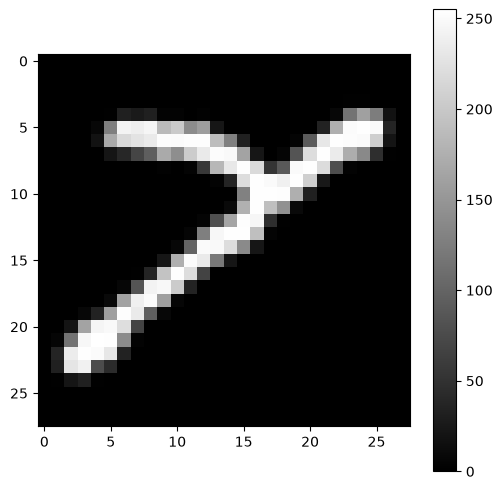

In [11]:
plt.figure(figsize=(6, 6))

plt.imshow(image[:, :, 0], cmap="gray")
plt.colorbar()

plt.show()

In [12]:
normalized_image = tf.cast(image, tf.float32) / 255.0

In [13]:
print("Original minimum:", tf.reduce_min(image).numpy())
print("Original maximum:", tf.reduce_max(image).numpy())

print("Normalized minimum:", tf.reduce_min(normalized_image).numpy())
print("Normalized maximum:", tf.reduce_max(normalized_image).numpy())

Original minimum: 0
Original maximum: 255
Normalized minimum: 0.0
Normalized maximum: 1.0


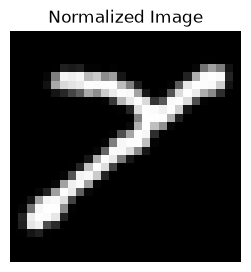

In [14]:
plt.figure(figsize=(3, 3))

plt.imshow(normalized_image[:, :, 0], cmap="gray")
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [19]:
print("Original pixel:", image[10, 20, 0].numpy())
print("Normalized pixel:", normalized_image[10, 20, 0].numpy())

Original pixel: 33
Normalized pixel: 0.12941177
